Etape 1 : EDA

In [1]:
!pip install wordcloud -q

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from wordcloud import WordCloud
import matplotlib.gridspec as gridspec

In [3]:
# Chargement & Nettoyage du Dataset

df = pd.read_csv('Restaurant reviews.csv')

# Suppression de la colonne parasite
df = df.drop(columns=['7514'], errors='ignore')

# Suppression des lignes sans Review ou Rating
df = df.dropna(subset=['Review', 'Rating'])

# Nettoyage du Rating : conversion numérique + arrondi (4.5→5, 1.5→2…)
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df = df.dropna(subset=['Rating'])
df['Rating'] = df['Rating'].apply(lambda x: round(x)).astype(int)

# Conversion du texte
df['Review'] = df['Review'].astype(str)

# Feature engineering texte
df['review_length']  = df['Review'].apply(len)
df['word_count']     = df['Review'].apply(lambda x: len(x.split()))
df['sentence_count'] = df['Review'].apply(
    lambda x: len([s for s in x.split('.') if s.strip()])
)

print("Dataset nettoyé")
print(f"   Shape          : {df.shape}")
print(f"   Restaurants    : {df['Restaurant'].nunique()}")
print(f"   Reviewers uniq : {df['Reviewer'].nunique()}")
print(f"   Valeurs nulles :\n{df.isnull().sum()}")

Dataset nettoyé
   Shape          : (9954, 10)
   Restaurants    : 100
   Reviewers uniq : 7442
   Valeurs nulles :
Restaurant        0
Reviewer          0
Review            0
Rating            0
Metadata          0
Time              0
Pictures          0
review_length     0
word_count        0
sentence_count    0
dtype: int64


In [4]:
display(df)

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,review_length,word_count,sentence_count
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0,222,41,5
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0,144,27,5
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0,189,31,5
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0,148,28,2
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0,160,27,7
...,...,...,...,...,...,...,...,...,...,...
9995,Chinese Pavilion,Abhishek Mahajan,Madhumathi Mahajan Well to start with nice cou...,3,"53 Reviews , 54 Followers",6/5/2016 0:08,0,1024,192,12
9996,Chinese Pavilion,Sharad Agrawal,This place has never disappointed us.. The foo...,4,"2 Reviews , 53 Followers",6/4/2016 22:01,0,320,52,6
9997,Chinese Pavilion,Ramandeep,"Bad rating is mainly because of ""Chicken Bone ...",2,"65 Reviews , 423 Followers",6/3/2016 10:37,3,1555,280,10
9998,Chinese Pavilion,Nayana Shanbhag,I personally love and prefer Chinese Food. Had...,4,"13 Reviews , 144 Followers",5/31/2016 17:22,0,511,88,8


In [5]:
# ── CELL 4 : Statistiques Descriptives ───────────────────────────────────────
print("=" * 50)
print("\nInformations générales :")
print("=" * 50)
df.info()
print("\n")
print("=" * 50)
print("       STATISTIQUES DESCRIPTIVES")
print("=" * 50)

print("\n📌 Distribution des Ratings :")
for r in [1, 2, 3, 4, 5]:
    n   = (df['Rating'] == r).sum()
    bar = '█' * int(n / len(df) * 50)
    print(f"  ⭐{r} : {n:>5} ({n/len(df)*100:5.1f}%)  {bar}")

print("\n📌 Longueur des avis (caractères) :")
print(df['review_length'].describe().round(1).to_string())

print("\n📌 Nombre de mots par avis :")
print(df['word_count'].describe().round(1).to_string())

print("\n📌 Mots moyens par note :")
print(df.groupby('Rating')['word_count'].mean().round(1).to_string())


Informations générales :
<class 'pandas.core.frame.DataFrame'>
Index: 9954 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Restaurant      9954 non-null   object
 1   Reviewer        9954 non-null   object
 2   Review          9954 non-null   object
 3   Rating          9954 non-null   int64 
 4   Metadata        9954 non-null   object
 5   Time            9954 non-null   object
 6   Pictures        9954 non-null   int64 
 7   review_length   9954 non-null   int64 
 8   word_count      9954 non-null   int64 
 9   sentence_count  9954 non-null   int64 
dtypes: int64(5), object(5)
memory usage: 1.1+ MB


       STATISTIQUES DESCRIPTIVES

📌 Distribution des Ratings :
  ⭐1 :  1735 ( 17.4%)  ████████
  ⭐2 :   712 (  7.2%)  ███
  ⭐3 :  1192 ( 12.0%)  █████
  ⭐4 :  2489 ( 25.0%)  ████████████
  ⭐5 :  3826 ( 38.4%)  ███████████████████

📌 Longueur des avis (caractères) :
count    9954.0
mean      

In [6]:
# ── CELL 5 : Palette & Style ──────────────────────────────────────────────────
PALETTE    = ['#E63946', '#F4A261', '#2A9D8F', '#457B9D', '#1D3557']
RATING_PAL = {1:'#E63946', 2:'#F4A261', 3:'#FFD166', 4:'#2A9D8F', 5:'#1D3557'}
CMAPS      = {1:'Reds', 2:'Oranges', 3:'YlOrBr', 4:'Greens', 5:'Blues'}
BG         = '#F8F9FA'

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'font.family'     : 'DejaVu Sans',
    'figure.facecolor': BG,
    'axes.facecolor'  : BG,
    'axes.edgecolor'  : '#CCCCCC'
})

/tmp/ipykernel_2394/901295312.py:95: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight', facecolor=BG)
/tmp/ipykernel_2394/901295312.py:95: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight', facecolor=BG)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


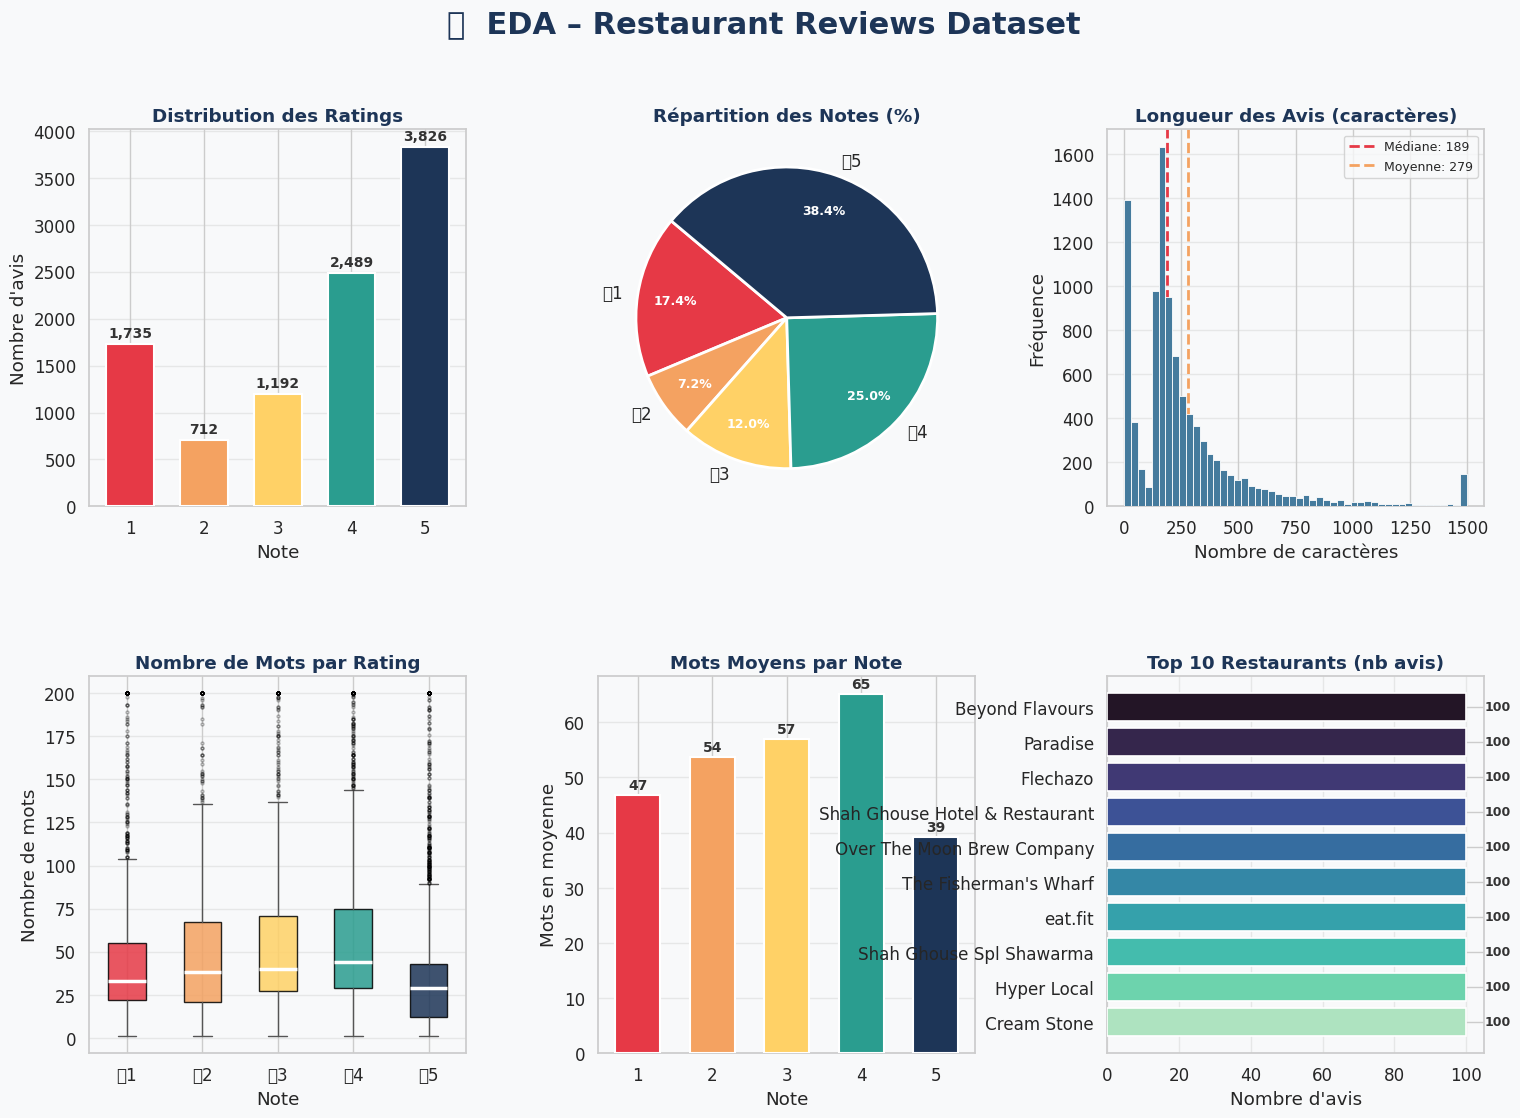

✅ Figure 1 sauvegardée : eda_overview.png


In [7]:
# ── CELL 6 : Figure 1 — Vue d'ensemble Statistique ───────────────────────────
fig = plt.figure(figsize=(18, 12), facecolor=BG)
fig.suptitle('📊  EDA – Restaurant Reviews Dataset',
             fontsize=22, fontweight='bold', color='#1D3557', y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1A – Distribution des ratings (barplot)
ax1 = fig.add_subplot(gs[0, 0])
counts = df['Rating'].value_counts().sort_index()
bars = ax1.bar(counts.index, counts.values,
               color=[RATING_PAL[r] for r in counts.index],
               edgecolor='white', linewidth=1.5, width=0.65, zorder=3)
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
             f'{val:,}', ha='center', va='bottom',
             fontsize=10, fontweight='bold', color='#333')
ax1.set_title('Distribution des Ratings', fontweight='bold', color='#1D3557')
ax1.set_xlabel('Note'); ax1.set_ylabel("Nombre d'avis")
ax1.set_xticks([1, 2, 3, 4, 5])
ax1.grid(axis='y', alpha=0.4); ax1.set_axisbelow(True)

# 1B – Répartition en camembert
ax2 = fig.add_subplot(gs[0, 1])
wedge_colors = [RATING_PAL[r] for r in counts.index]
wedges, texts, autotexts = ax2.pie(
    counts.values,
    labels=[f'⭐{r}' for r in counts.index],
    autopct='%1.1f%%',
    colors=wedge_colors,
    startangle=140,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(9); at.set_color('white'); at.set_fontweight('bold')
ax2.set_title('Répartition des Notes (%)', fontweight='bold', color='#1D3557')

# 1C – Distribution longueur des avis
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(df['review_length'].clip(upper=1500), bins=50,
         color='#457B9D', edgecolor='white', linewidth=0.6, zorder=3)
ax3.axvline(df['review_length'].median(), color='#E63946', lw=2,
            linestyle='--', label=f"Médiane: {int(df['review_length'].median())}")
ax3.axvline(df['review_length'].mean(),   color='#F4A261', lw=2,
            linestyle='--', label=f"Moyenne: {int(df['review_length'].mean())}")
ax3.legend(fontsize=9)
ax3.set_title('Longueur des Avis (caractères)', fontweight='bold', color='#1D3557')
ax3.set_xlabel('Nombre de caractères'); ax3.set_ylabel('Fréquence')
ax3.grid(axis='y', alpha=0.4); ax3.set_axisbelow(True)

# 1D – Boxplot word_count × rating
ax4 = fig.add_subplot(gs[1, 0])
data_box = [df[df['Rating'] == r]['word_count'].clip(upper=200).values
            for r in [1, 2, 3, 4, 5]]
bp = ax4.boxplot(data_box, patch_artist=True,
                 medianprops=dict(color='white', linewidth=2.5),
                 whiskerprops=dict(color='#555'),
                 capprops=dict(color='#555'),
                 flierprops=dict(marker='o', markersize=2, alpha=0.3))
for patch, color in zip(bp['boxes'], [RATING_PAL[r] for r in [1, 2, 3, 4, 5]]):
    patch.set_facecolor(color); patch.set_alpha(0.85)
ax4.set_xticklabels([f'⭐{r}' for r in [1, 2, 3, 4, 5]])
ax4.set_title('Nombre de Mots par Rating', fontweight='bold', color='#1D3557')
ax4.set_xlabel('Note'); ax4.set_ylabel('Nombre de mots')
ax4.grid(axis='y', alpha=0.4); ax4.set_axisbelow(True)

# 1E – Mots moyens par note (barplot)
ax5 = fig.add_subplot(gs[1, 1])
avg_wc = df.groupby('Rating')['word_count'].mean().reindex([1, 2, 3, 4, 5])
bars5 = ax5.bar(avg_wc.index, avg_wc.values,
                color=[RATING_PAL[r] for r in avg_wc.index],
                edgecolor='white', linewidth=1.5, width=0.6, zorder=3)
for bar, val in zip(bars5, avg_wc.values):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.0f}', ha='center', va='bottom',
             fontsize=10, fontweight='bold', color='#333')
ax5.set_title('Mots Moyens par Note', fontweight='bold', color='#1D3557')
ax5.set_xlabel('Note'); ax5.set_ylabel('Mots en moyenne')
ax5.set_xticks([1, 2, 3, 4, 5])
ax5.grid(axis='y', alpha=0.4); ax5.set_axisbelow(True)

# 1F – Top 10 restaurants
ax6 = fig.add_subplot(gs[1, 2])
top_rest = df['Restaurant'].value_counts().head(10)
bars6 = ax6.barh(top_rest.index[::-1], top_rest.values[::-1],
                 color=sns.color_palette('mako_r', 10),
                 edgecolor='white', linewidth=1.2, zorder=3)
for bar, val in zip(bars6, top_rest.values[::-1]):
    ax6.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=9, fontweight='bold', color='#333')
ax6.set_title('Top 10 Restaurants (nb avis)', fontweight='bold', color='#1D3557')
ax6.set_xlabel("Nombre d'avis")
ax6.grid(axis='x', alpha=0.4); ax6.set_axisbelow(True)

plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("✅ Figure 1 sauvegardée : eda_overview.png")

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipykernel_2394/541677523.py:65: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight', facecolor=BG)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


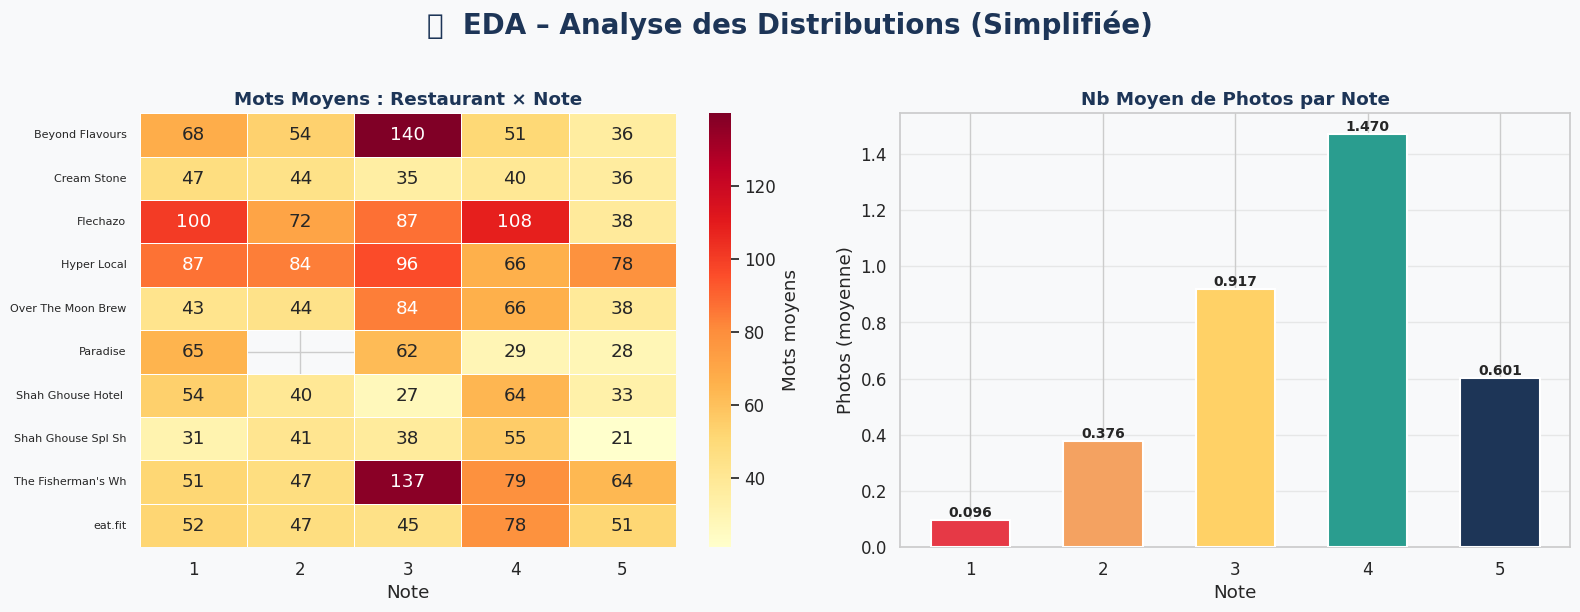

✅ Figure simplifiée sauvegardée : eda_distributions.png


In [8]:
# ── CELL 7 : Figure 2 — Distributions (version simplifiée) ─────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=BG)

fig.suptitle('📈  EDA – Analyse des Distributions (Simplifiée)',
             fontsize=20, fontweight='bold', color='#1D3557', y=1.02)
# ── 2C – Heatmap mots moyens : restaurant × rating ─────────────────
ax = axes[0]
top10 = df['Restaurant'].value_counts().head(10).index
heat_data = df[df['Restaurant'].isin(top10)].pivot_table(
    values='word_count',
    index='Restaurant',
    columns='Rating',
    aggfunc='mean'
)
# raccourcir les noms
heat_data.index = [r[:18] for r in heat_data.index]
sns.heatmap(
    heat_data,
    ax=ax,
    cmap='YlOrRd',
    annot=True,
    fmt='.0f',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Mots moyens'}
)
ax.set_title('Mots Moyens : Restaurant × Note', fontweight='bold', color='#1D3557')
ax.set_xlabel('Note')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=8)

# ── 2D – Photos moyennes par note ─────────────────
ax = axes[1]
pic_avg = df.groupby('Rating')['Pictures'].mean().reindex([1, 2, 3, 4, 5])
bars = ax.bar(
    pic_avg.index,
    pic_avg.values,
    color=[RATING_PAL[r] for r in pic_avg.index],
    edgecolor='white',
    linewidth=1.5,
    width=0.6,
    zorder=3
)
# affichage des valeurs
for bar, val in zip(bars, pic_avg.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.002,
        f'{val:.3f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )
ax.set_title('Nb Moyen de Photos par Note', fontweight='bold', color='#1D3557')
ax.set_xlabel('Note')
ax.set_ylabel('Photos (moyenne)')
ax.set_xticks([1, 2, 3, 4, 5])
ax.grid(axis='y', alpha=0.4)
ax.set_facecolor(BG)

# ── Final ─────────────────
plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

print("✅ Figure simplifiée sauvegardée : eda_distributions.png")

/tmp/ipykernel_2394/1055287960.py:65: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig('eda_wordclouds.png', dpi=150, bbox_inches='tight', facecolor=BG)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


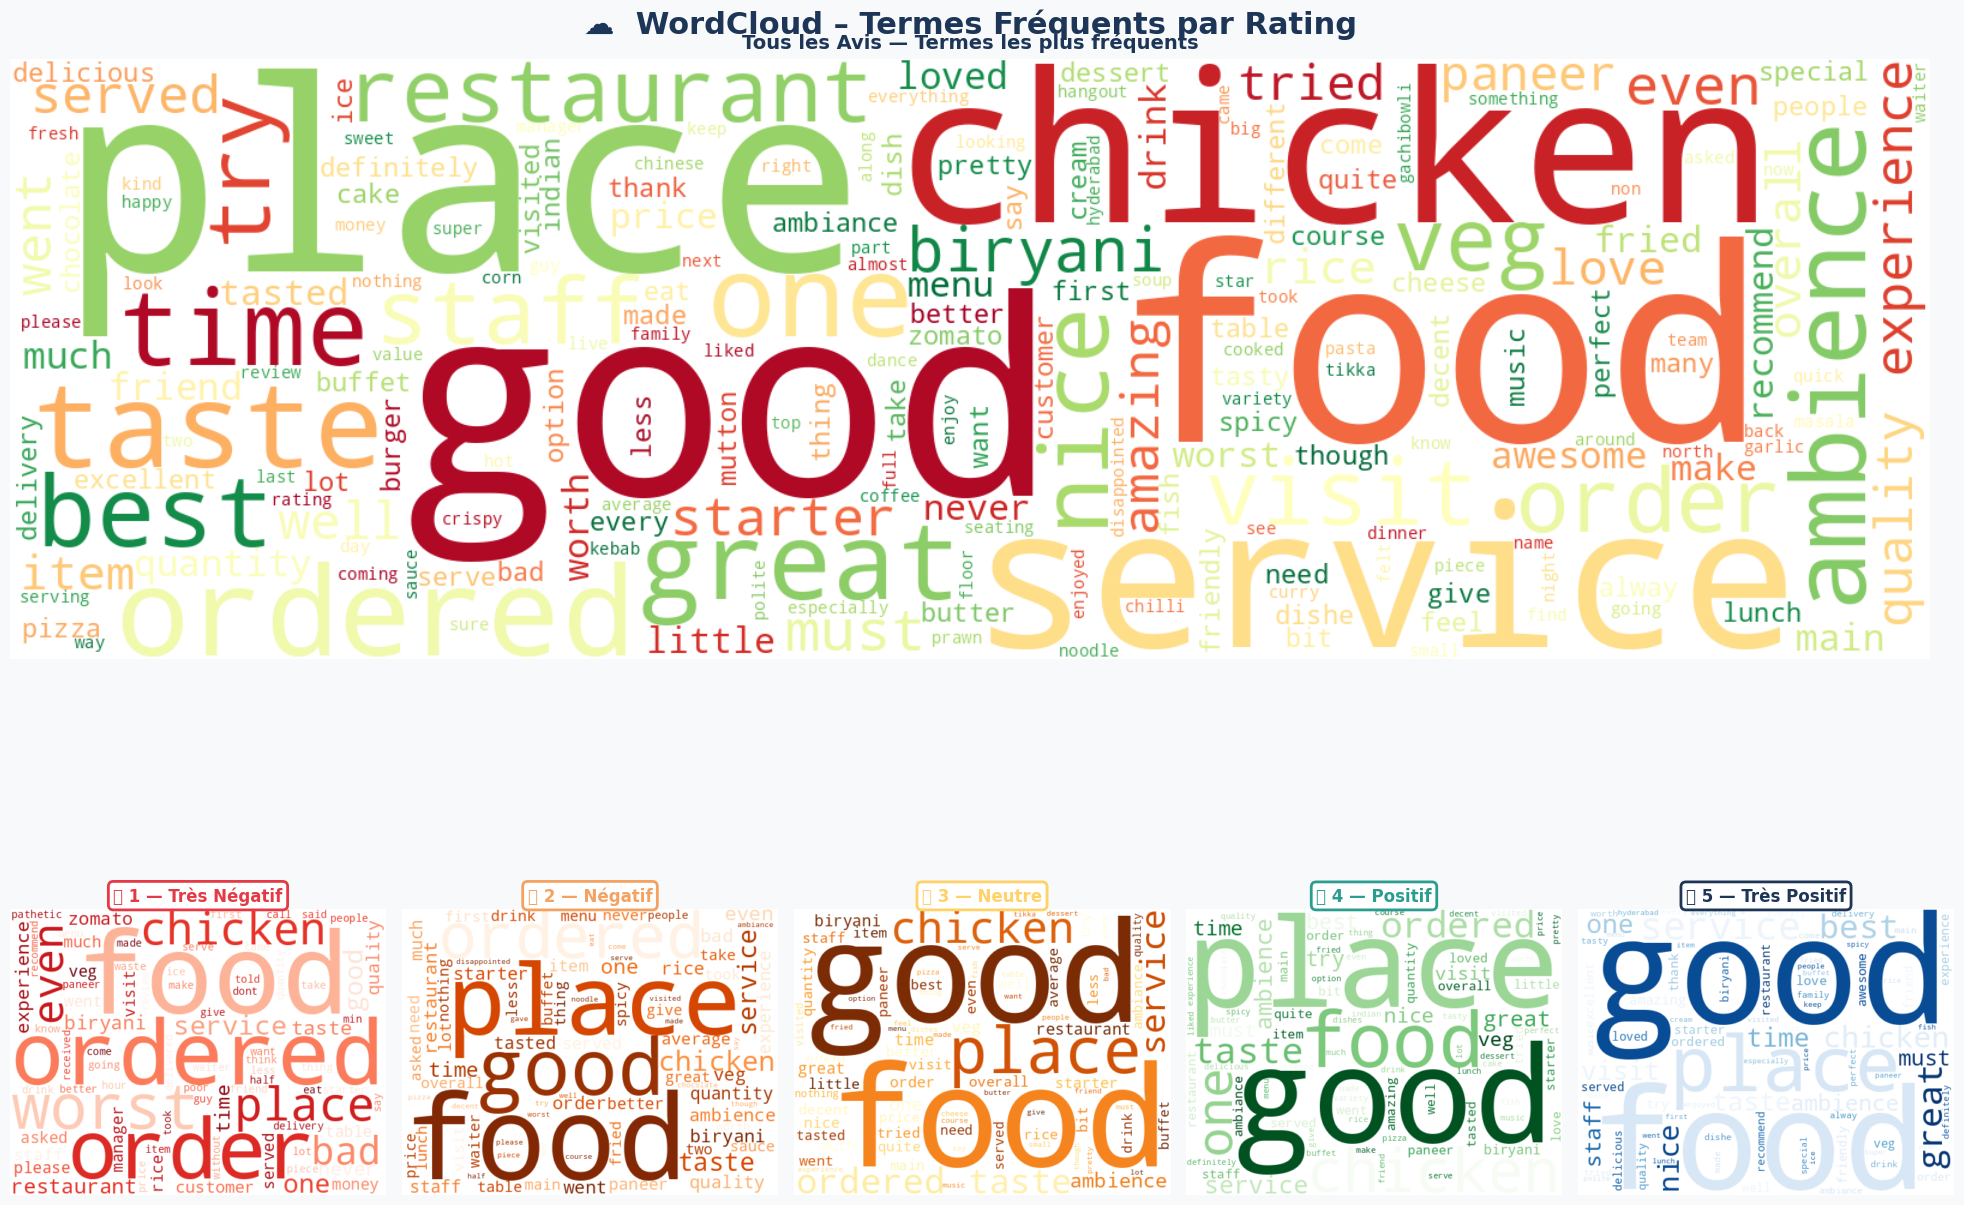

✅ Figure 3 sauvegardée : eda_wordclouds.png


In [9]:
# ── CELL 8 : Figure 3 — WordClouds ───────────────────────────────────────────
# Stopwords personnalisés (sans NLTK pour l'instant)
STOP = set([
    'the','a','an','and','or','is','was','were','are','be','been',
    'to','of','in','it','i','we','they','he','she','for','with',
    'this','that','my','our','very','so','but','on','at','have',
    'had','has','not','from','all','also','as','by','its','your',
    'me','us','their','would','could','did','do','you','get','got',
    'just','really','which','when','who','if','up','out','there',
    'here','some','can','about','than','what','no','will','more'
])

def make_text(rating_list):
    """Construit un corpus de texte pour une liste de ratings donnée."""
    reviews = df[df['Rating'].isin(rating_list)]['Review'].str.lower()
    words   = ' '.join(reviews)
    words   = ' '.join([
        w for w in words.split()
        if w.isalpha() and w not in STOP and len(w) > 2
    ])
    return words

fig = plt.figure(figsize=(20, 14), facecolor=BG)
fig.suptitle('☁️  WordCloud – Termes Fréquents par Rating',
             fontsize=22, fontweight='bold', color='#1D3557', y=0.99)

# WordCloud global (tous les avis)
ax_global = fig.add_axes([0.02, 0.52, 0.96, 0.44])
global_text = make_text([1, 2, 3, 4, 5])
wc_global = WordCloud(
    width=1600, height=500, background_color='white',
    colormap='RdYlGn', max_words=200,
    prefer_horizontal=0.85, collocations=False
).generate(global_text)
ax_global.imshow(wc_global, interpolation='bilinear')
ax_global.axis('off')
ax_global.set_title('Tous les Avis — Termes les plus fréquents',
                    fontsize=14, fontweight='bold', color='#1D3557', pad=8)

# WordCloud par rating (1 à 5)
label_map = {1: 'Très Négatif', 2: 'Négatif', 3: 'Neutre',
             4: 'Positif',      5: 'Très Positif'}
positions = [(0.02 + i * 0.196, 0.01, 0.188, 0.47) for i in range(5)]

for i, r in enumerate([1, 2, 3, 4, 5]):
    ax = fig.add_axes(positions[i])
    text = make_text([r])
    if not text.strip():
        ax.axis('off')
        continue
    wc = WordCloud(
        width=500, height=380, background_color='white',
        colormap=CMAPS[r], max_words=80,
        prefer_horizontal=0.85, collocations=False
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(
        f'⭐ {r} — {label_map[r]}',
        fontsize=12, fontweight='bold', color=RATING_PAL[r], pad=6,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor=RATING_PAL[r], linewidth=2)
    )

plt.savefig('eda_wordclouds.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("✅ Figure 3 sauvegardée : eda_wordclouds.png")

In [10]:
# ── CELL 9 : Résumé Final ─────────────────────────────────────────────────────
print("\n" + "="*55)
print("          ✅  PHASE 1 — EDA TERMINÉE")
print("="*55)
print(f"  • Dataset final    : {df.shape[0]:,} avis | {df.shape[1]} colonnes")
print(f"  • Restaurants      : {df['Restaurant'].nunique()} uniques")
print(f"  • Longueur moyenne : {df['review_length'].mean():.0f} caractères")
print(f"  • Mots moyens      : {df['word_count'].mean():.0f} mots/avis")
print(f"  • Classe dominante : ⭐5 ({(df['Rating']==5).mean()*100:.1f}%)")
print(f"  • Classe rare      : ⭐2 ({(df['Rating']==2).mean()*100:.1f}%)")
print("\n  📁 Fichiers générés :")
print("     - eda_overview.png")
print("     - eda_distributions.png")
print("     - eda_wordclouds.png")
print("="*55)


          ✅  PHASE 1 — EDA TERMINÉE
  • Dataset final    : 9,954 avis | 10 colonnes
  • Restaurants      : 100 uniques
  • Longueur moyenne : 280 caractères
  • Mots moyens      : 50 mots/avis
  • Classe dominante : ⭐5 (38.4%)
  • Classe rare      : ⭐2 (7.2%)

  📁 Fichiers générés :
     - eda_overview.png
     - eda_distributions.png
     - eda_wordclouds.png


Phase 2 : Ingénierie du Texte

In [11]:
!pip install nltk spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 90.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [12]:
import nltk
import spacy
import re

from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [13]:
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

nlp = spacy.load("en_core_web_sm")

1. Nettoyage (NLTK)

In [14]:
stop_words = set(stopwords.words('english'))

In [15]:
def preprocesser_nltk(texte):
  if pd.isna(texte):
    return []

  # Minuscule + suppression ponctuation
  texte_net = re.sub(r'[^\w\s]', ' ', str(texte).lower())

  # Tokenisation
  tokens = word_tokenize(texte_net)

  # Filtrage
  tokens = [t for t in tokens if t not in stop_words and len(t) > 2]

  return tokens

In [16]:
df['tokens'] = df['Review'].apply(preprocesser_nltk)

In [17]:
df['clean_text'] = df['tokens'].apply(lambda x: " ".join(x))

In [18]:
# Aplatir la liste
tous_mots = [mot for tokens in df['tokens'] for mot in tokens]

# Compter
freq_mots = Counter(tous_mots)

# Top 10
print("\n Top 10 mots les plus fréquents :")
for mot, count in freq_mots.most_common(10):
    print(f"{mot} : {count}")


 Top 10 mots les plus fréquents :
good : 7230
food : 6641
place : 5734
service : 3246
chicken : 3105
taste : 2282
ordered : 2178
ambience : 2126
great : 1978
one : 1942


In [19]:
display(df)

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,review_length,word_count,sentence_count,tokens,clean_text
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0,222,41,5,"[ambience, good, food, quite, good, saturday, ...",ambience good food quite good saturday lunch c...
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0,144,27,5,"[ambience, good, pleasant, evening, service, p...",ambience good pleasant evening service prompt ...
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0,189,31,5,"[must, try, great, food, great, ambience, thnx...",must try great food great ambience thnx servic...
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0,148,28,2,"[soumen, das, arun, great, guy, behavior, sinc...",soumen das arun great guy behavior sincerety g...
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0,160,27,7,"[food, good, ordered, kodi, drumsticks, basket...",food good ordered kodi drumsticks basket mutto...
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Chinese Pavilion,Abhishek Mahajan,Madhumathi Mahajan Well to start with nice cou...,3,"53 Reviews , 54 Followers",6/5/2016 0:08,0,1024,192,12,"[madhumathi, mahajan, well, start, nice, court...",madhumathi mahajan well start nice courteous s...
9996,Chinese Pavilion,Sharad Agrawal,This place has never disappointed us.. The foo...,4,"2 Reviews , 53 Followers",6/4/2016 22:01,0,320,52,6,"[place, never, disappointed, food, courteous, ...",place never disappointed food courteous staff ...
9997,Chinese Pavilion,Ramandeep,"Bad rating is mainly because of ""Chicken Bone ...",2,"65 Reviews , 423 Followers",6/3/2016 10:37,3,1555,280,10,"[bad, rating, mainly, chicken, bone, found, ve...",bad rating mainly chicken bone found veg food ...
9998,Chinese Pavilion,Nayana Shanbhag,I personally love and prefer Chinese Food. Had...,4,"13 Reviews , 144 Followers",5/31/2016 17:22,0,511,88,8,"[personally, love, prefer, chinese, food, coup...",personally love prefer chinese food couple tim...


2. Analyse Linguistique (spaCy)

In [20]:
def analyser_spacy(texte):
  if pd.isna(texte):
    return [], [], []
  # Passage dans spaCy
  doc = nlp(texte)

  # 1. Lemmatisation
  lemmes = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct]

  # 2. Entités nommées (NER)
  entites = [(ent.text, ent.label_) for ent in doc.ents]

  # 3. Adjectifs
  adjectifs = [token.text for token in doc if token.pos_ == "ADJ"]

  return lemmes, entites, adjectifs

In [21]:
# 🔹 Appliquer la fonction
df['lemmes_spacy'], df['entites_spacy'], df['adjectifs'] = zip(*df['Review'].apply(analyser_spacy))

print(" Analyse spaCy terminée")

 Analyse spaCy terminée


In [22]:
display(df[['Review', 'lemmes_spacy', 'entites_spacy', 'adjectifs']].head())

,Review,lemmes_spacy,entites_spacy,adjectifs
0,"The ambience was good, food was quite good . h...","[ambience, good, food, good, Saturday, lunch, ...","[(Saturday, DATE)]","[good, good, effective, Good, sate, courteous,..."
1,Ambience is too good for a pleasant evening. S...,"[ambience, good, pleasant, evening, service, p...","[(Soumen Das - kudos, PERSON)]","[good, pleasant, prompt, good, good]"
2,A must try.. great food great ambience. Thnx f...,"[try, great, food, great, ambience, Thnx, serv...","[(Pradeep, ORG), (Subroto, PERSON), (Penne Alf...","[great, great, personal, amazing]"
3,Soumen das and Arun was a great guy. Only beca...,"[Soumen, das, Arun, great, guy, behavior, sinc...","[(Arun, PERSON)]","[great, good]"
4,Food is good.we ordered Kodi drumsticks and ba...,"[food, good.we, order, Kodi, drumstick, basket...","[(Kodi, PERSON), (biryani, PERSON)]","[good, good]"


In [23]:
idx = 5

print(f"--- Avis N°{idx} ---")
print(f"Original : {df['Review'].iloc[idx]}")
print(f"Tokens NLTK : {df['tokens'].iloc[idx]}")
print(f"Lemmes spaCy : {df['lemmes_spacy'].iloc[idx]}")
print(f"Entités : {df['entites_spacy'].iloc[idx]}")
print(f"Adjectifs : {df['adjectifs'].iloc[idx]}")

--- Avis N°5 ---
Original : Ambiance is good, service is good, food is aPradeecp and subro best service
Food is good. Papiya good hostess and ur caption very good. This is 4star restaurant.
Tokens NLTK : ['ambiance', 'good', 'service', 'good', 'food', 'apradeecp', 'subro', 'best', 'service', 'food', 'good', 'papiya', 'good', 'hostess', 'caption', 'good', '4star', 'restaurant']
Lemmes spaCy : ['ambiance', 'good', 'service', 'good', 'food', 'aPradeecp', 'subro', 'good', 'service', '\n', 'Food', 'good', 'Papiya', 'good', 'hostess', 'ur', 'caption', 'good', '4star', 'restaurant']
Entités : [('aPradeecp', 'ORG'), ('Papiya', 'ORG'), ('4star', 'CARDINAL')]
Adjectifs : ['good', 'good', 'best', 'good', 'good', 'good']


/tmp/ipykernel_2394/295035539.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=values, y=labels, palette='magma')


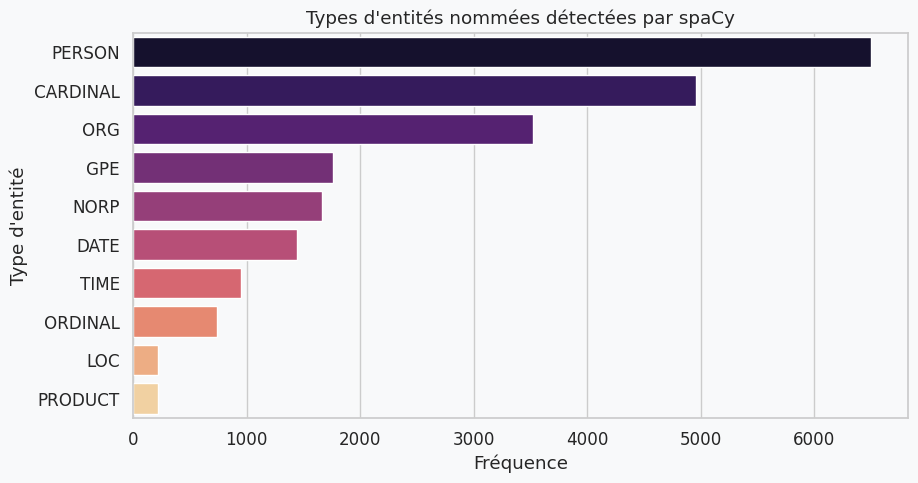

In [24]:
# Extraire types d'entités
types_entites = [label for entities in df['entites_spacy'] for _, label in entities]

# Compter
freq_entites = Counter(types_entites)

# Top 10
top_entites = freq_entites.most_common(10)

labels = [x[0] for x in top_entites]
values = [x[1] for x in top_entites]

#sns.barplot(x=list(freq_entites.values())[:10], y=list(freq_entites.keys())[:10],palette='magma')
# Plot
plt.figure(figsize=(10,5))
sns.barplot(x=values, y=labels, palette='magma')

plt.title("Types d'entités nommées détectées par spaCy")
plt.xlabel("Fréquence")
plt.ylabel("Type d'entité")
plt.show()

Phase 3 : Modélisation Avancée (Gensim & IA)

In [25]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 67.2 MB/s eta 0:00:00


In [26]:
import gensim
from gensim import corpora, models

In [27]:
# Dictionnaire (mot → id)
dictionary = corpora.Dictionary(df['tokens'])

# Corpus (Bag of Words)
corpus = [dictionary.doc2bow(tokens) for tokens in df['tokens']]

In [28]:
# Entraînement du modèle LDA
lda_model = models.LdaModel(
corpus=corpus,
id2word=dictionary,
num_topics=2,
random_state=42,
passes=10,
alpha='auto'
)

In [29]:
print("Thèmes détectés par LDA :")
print(lda_model.print_topics(num_words=5))

Thèmes détectés par LDA :
[(0, '0.021*"chicken" + 0.014*"ordered" + 0.010*"taste" + 0.008*"food" + 0.008*"one"'), (1, '0.047*"good" + 0.041*"food" + 0.037*"place" + 0.023*"service" + 0.016*"ambience"')]


In [30]:
# Embeddings de Mots (Word2Vec)
w2v_model = models.Word2Vec(
    sentences=df['tokens'],
    vector_size=50,
    window=4,
    min_count=2,
    workers=4,
    epochs=15
)

In [31]:
mot_recherche = 'good'

print(f"\nMots proches de '{mot_recherche}' :")

try:
    similaires = w2v_model.wv.most_similar(mot_recherche, topn=5)

    for mot, score in similaires:
        print(f"{mot} : {score:.3f}")

except KeyError:
    print(f" '{mot_recherche}' n'existe pas dans le vocabulaire")
    print(" Essayez avec :", list(w2v_model.wv.index_to_key)[:5])


Mots proches de 'good' :
great : 0.825
nice : 0.822
decent : 0.810
superb : 0.738
average : 0.716


In [32]:
display(df)

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,review_length,word_count,sentence_count,tokens,clean_text,lemmes_spacy,entites_spacy,adjectifs
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0,222,41,5,"[ambience, good, food, quite, good, saturday, ...",ambience good food quite good saturday lunch c...,"[ambience, good, food, good, Saturday, lunch, ...","[(Saturday, DATE)]","[good, good, effective, Good, sate, courteous,..."
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0,144,27,5,"[ambience, good, pleasant, evening, service, p...",ambience good pleasant evening service prompt ...,"[ambience, good, pleasant, evening, service, p...","[(Soumen Das - kudos, PERSON)]","[good, pleasant, prompt, good, good]"
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0,189,31,5,"[must, try, great, food, great, ambience, thnx...",must try great food great ambience thnx servic...,"[try, great, food, great, ambience, Thnx, serv...","[(Pradeep, ORG), (Subroto, PERSON), (Penne Alf...","[great, great, personal, amazing]"
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0,148,28,2,"[soumen, das, arun, great, guy, behavior, sinc...",soumen das arun great guy behavior sincerety g...,"[Soumen, das, Arun, great, guy, behavior, sinc...","[(Arun, PERSON)]","[great, good]"
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0,160,27,7,"[food, good, ordered, kodi, drumsticks, basket...",food good ordered kodi drumsticks basket mutto...,"[food, good.we, order, Kodi, drumstick, basket...","[(Kodi, PERSON), (biryani, PERSON)]","[good, good]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Chinese Pavilion,Abhishek Mahajan,Madhumathi Mahajan Well to start with nice cou...,3,"53 Reviews , 54 Followers",6/5/2016 0:08,0,1024,192,12,"[madhumathi, mahajan, well, start, nice, court...",madhumathi mahajan well start nice courteous s...,"[Madhumathi, Mahajan, start, nice, courteous, ...","[(Mix XO, ORG), (Nash, PERSON), (wifey, ORG), ...","[nice, courteous, Excellent, little, next, nic..."
9996,Chinese Pavilion,Sharad Agrawal,This place has never disappointed us.. The foo...,4,"2 Reviews , 53 Followers",6/4/2016 22:01,0,320,52,6,"[place, never, disappointed, food, courteous, ...",place never disappointed food courteous staff ...,"[place, disappoint, food, courteous, staff, se...","[(Chicken, PERSON), (Thanks Chinese Pavilion, ...","[courteous, serene, free, little, chilly, garl..."
9997,Chinese Pavilion,Ramandeep,"Bad rating is mainly because of ""Chicken Bone ...",2,"65 Reviews , 423 Followers",6/3/2016 10:37,3,1555,280,10,"[bad, rating, mainly, chicken, bone, found, ve...",bad rating mainly chicken bone found veg food ...,"[bad, rating, mainly, Chicken, Bone, find, Veg...","[(Chicken Bone, PERSON), (Vegetarian, NORP), (...","[Bad, acceptable, chinese, available, voucher,..."
9998,Chinese Pavilion,Nayana Shanbhag,I personally love and prefer Chinese Food. Had...,4,"13 Reviews , 144 Followers",5/31/2016 17:22,0,511,88,8,"[personally, love, prefer, chinese, food, coup...",personally love prefer chinese food couple tim...,"[personally, love, prefer, chinese, Food, coup...","[(Chinese Food, ORG)]","[Chinese, good, polite, small, comfy, crowded,..."


Machine & Deep Learning

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import LabelEncoder
from sklearn.metrics         import (accuracy_score, f1_score,
                                     classification_report, confusion_matrix)

In [34]:
def map_sentiment(r):
    if r <= 2: return 'Negatif'
    if r == 3: return 'Neutre'
    return 'Positif'

df['Sentiment'] = df['Rating'].apply(map_sentiment)
print(df['Sentiment'].value_counts())

Sentiment
Positif    6315
Negatif    2447
Neutre     1192
Name: count, dtype: int64


In [35]:
# ── CELL 3 : Encodage & Split ─────────────────────────────────────────────────
le = LabelEncoder()
y  = le.fit_transform(df['Sentiment'])
X  = df['clean_text'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 7963 | Test: 1991


In [36]:
# ── CELL 3 : Encodage & Split ─────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter

le = LabelEncoder()
y  = le.fit_transform(df['Sentiment'])
X  = df['clean_text'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Distribution avant SMOTE : {Counter(y_train)}")

# ── SMOTE (sur vecteurs TF-IDF temporaires) ───────────────────────────────────
tfidf         = TfidfVectorizer(max_features=20000)
X_train_vec   = tfidf.fit_transform(X_train)
X_test_vec    = tfidf.transform(X_test)



sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_vec, y_train)

print(f"Distribution après SMOTE  : {Counter(y_train_res)}")

Train: 7963 | Test: 1991
Distribution avant SMOTE : Counter({np.int64(2): 5052, np.int64(0): 1957, np.int64(1): 954})
Distribution après SMOTE  : Counter({np.int64(0): 5052, np.int64(2): 5052, np.int64(1): 5052})


In [37]:
# ══════════════════════════════════════════════════════════════════════════════
#  MODÈLE 1 — SVM  (TF-IDF obligatoire : SVM ne lit pas du texte brut)
# ══════════════════════════════════════════════════════════════════════════════
# ⚠️ TF-IDF ici n'est PAS un prétraitement texte — c'est la vectorisation
#    numérique INDISPENSABLE pour que SVM puisse travailler (entrée = nombres)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

tfidf         = TfidfVectorizer(max_features=20000)
X_train_vec   = tfidf.fit_transform(X_train)
X_test_vec    = tfidf.transform(X_test)

svm = LinearSVC(class_weight='balanced', random_state=42)
svm.fit(X_train_res, y_train_res)
y_pred_svm = svm.predict(X_test_vec)

acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm  = f1_score(y_test, y_pred_svm, average='weighted')

print("\n===== SVM =====")
print(f"Accuracy : {acc_svm:.4f}  |  F1 : {f1_svm:.4f}")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))


===== SVM =====
Accuracy : 0.7860  |  F1 : 0.7912
              precision    recall  f1-score   support

     Negatif       0.76      0.77      0.77       490
      Neutre       0.31      0.36      0.33       238
     Positif       0.90      0.87      0.89      1263

    accuracy                           0.79      1991
   macro avg       0.66      0.67      0.66      1991
weighted avg       0.80      0.79      0.79      1991



In [38]:
# ══════════════════════════════════════════════════════════════════════════════
#  MODÈLE 2 — LSTM  (Tokenization + Padding obligatoires : LSTM = séquences)
# ══════════════════════════════════════════════════════════════════════════════
# ⚠️ Tokenization + Padding ici ne sont PAS un prétraitement texte —
#    ce sont les étapes obligatoires pour convertir le texte en séquences
#    d'entiers de longueur fixe que le LSTM peut lire (entrée = tenseurs)

import tensorflow as tf
from tensorflow.keras.models     import Sequential
from tensorflow.keras.layers     import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text     import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks  import EarlyStopping

VOCAB   = 15000
MAX_LEN = 100

tokenizer   = Tokenizer(num_words=VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN, padding='post')
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test),  maxlen=MAX_LEN, padding='post')

num_classes = len(le.classes_)
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes)

model = Sequential([
    Embedding(VOCAB, 64, input_length=MAX_LEN),
    LSTM(128),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train_seq, y_train_cat,
    validation_split=0.15,
    epochs=15, batch_size=64,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=1
)

y_pred_lstm = np.argmax(model.predict(X_test_seq, verbose=0), axis=1)
acc_lstm = accuracy_score(y_test, y_pred_lstm)
f1_lstm  = f1_score(y_test, y_pred_lstm, average='weighted')

print("\n===== LSTM =====")
print(f"Accuracy : {acc_lstm:.4f}  |  F1 : {f1_lstm:.4f}")
print(classification_report(y_test, y_pred_lstm, target_names=le.classes_))

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


106/106 ━━━━━━━━━━━━━━━━━━━━ 23s 186ms/step - accuracy: 0.6269 - loss: 0.9076 - val_accuracy: 0.6494 - val_loss: 0.8701
Epoch 2/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 22s 210ms/step - accuracy: 0.6318 - loss: 0.8962 - val_accuracy: 0.6494 - val_loss: 0.8679
Epoch 3/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 39s 195ms/step - accuracy: 0.6318 - loss: 0.8931 - val_accuracy: 0.6494 - val_loss: 0.8666
Epoch 4/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 21s 196ms/step - accuracy: 0.6322 - loss: 0.8909 - val_accuracy: 0.6494 - val_loss: 0.8712
Epoch 5/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 20s 193ms/step - accuracy: 0.6376 - loss: 0.8920 - val_accuracy: 0.6494 - val_loss: 0.8541
Epoch 6/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 22s 200ms/step - accuracy: 0.6315 - loss: 0.8528 - val_accuracy: 0.6728 - val_loss: 0.8079
Epoch 7/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 21s 194ms/step - accuracy: 0.6464 - loss: 0.8399 - val_accuracy: 0.6720 - val_loss: 0.8056
Epoch 8/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 40s 184ms/step - accuracy: 0.6526 - loss: 0.8379 - val

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


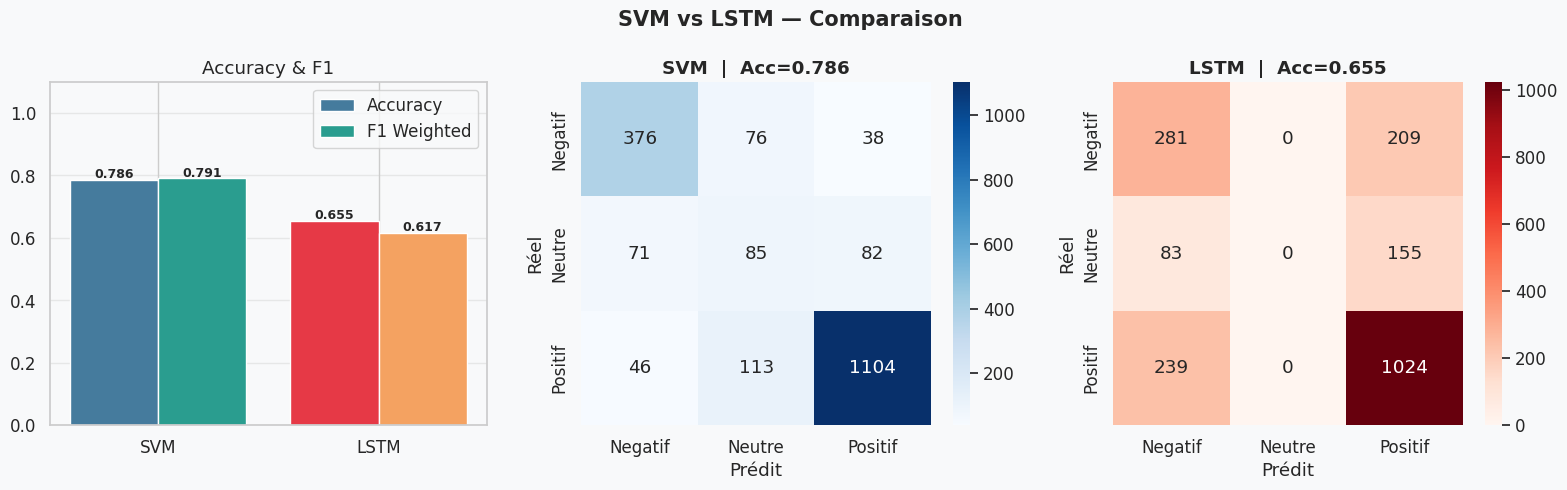

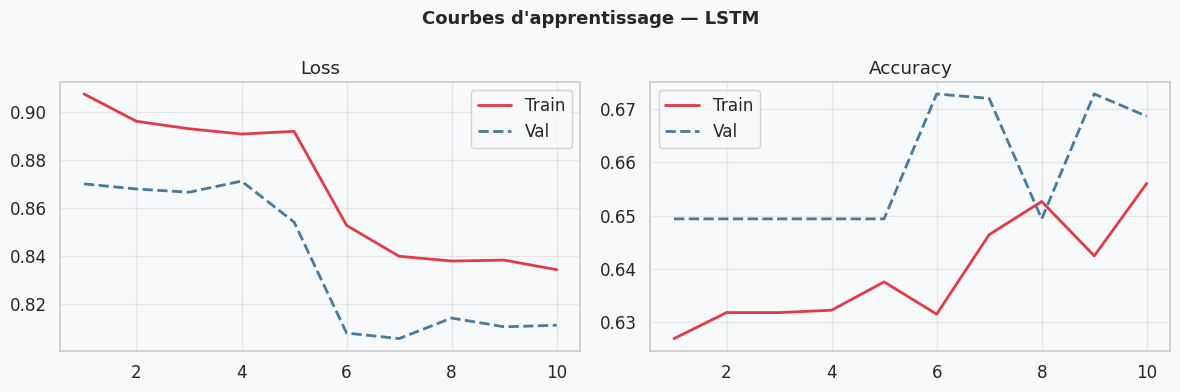


  SVM  | Accuracy: 0.7860 | F1: 0.7912
  LSTM | Accuracy: 0.6554 | F1: 0.6166
  Meilleur : SVM


In [39]:
# ══════════════════════════════════════════════════════════════════════════════
#  VISUALISATIONS
# ══════════════════════════════════════════════════════════════════════════════

# Figure 1 — Comparaison + Matrices de confusion
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('SVM vs LSTM — Comparaison', fontsize=15, fontweight='bold')

ax = axes[0]
x  = np.arange(2)
ax.bar(x - 0.2, [acc_svm, acc_lstm], 0.4, label='Accuracy',    color=['#457B9D', '#E63946'])
ax.bar(x + 0.2, [f1_svm,  f1_lstm],  0.4, label='F1 Weighted', color=['#2A9D8F', '#F4A261'])
for i, (a, f) in enumerate(zip([acc_svm, acc_lstm], [f1_svm, f1_lstm])):
    ax.text(i - 0.2, a + 0.005, f'{a:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.text(i + 0.2, f + 0.005, f'{f:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(['SVM', 'LSTM'])
ax.set_ylim(0, 1.1); ax.set_title('Accuracy & F1')
ax.legend(); ax.grid(axis='y', alpha=0.4)

sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d',
            cmap='Blues', ax=axes[1], xticklabels=le.classes_, yticklabels=le.classes_)
axes[1].set_title(f'SVM  |  Acc={acc_svm:.3f}', fontweight='bold')
axes[1].set_xlabel('Prédit'); axes[1].set_ylabel('Réel')

sns.heatmap(confusion_matrix(y_test, y_pred_lstm), annot=True, fmt='d',
            cmap='Reds', ax=axes[2], xticklabels=le.classes_, yticklabels=le.classes_)
axes[2].set_title(f'LSTM  |  Acc={acc_lstm:.3f}', fontweight='bold')
axes[2].set_xlabel('Prédit'); axes[2].set_ylabel('Réel')

plt.tight_layout()
plt.savefig('svm_vs_lstm.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 2 — Courbes LSTM
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Courbes d'apprentissage — LSTM", fontsize=13, fontweight='bold')
ep = range(1, len(history.history['loss']) + 1)

axes[0].plot(ep, history.history['loss'],     label='Train', color='#E63946', lw=2)
axes[0].plot(ep, history.history['val_loss'], label='Val',   color='#457B9D', lw=2, linestyle='--')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.4)

axes[1].plot(ep, history.history['accuracy'],     label='Train', color='#E63946', lw=2)
axes[1].plot(ep, history.history['val_accuracy'], label='Val',   color='#457B9D', lw=2, linestyle='--')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig('lstm_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Résumé
print("\n" + "="*40)
print(f"  SVM  | Accuracy: {acc_svm:.4f} | F1: {f1_svm:.4f}")
print(f"  LSTM | Accuracy: {acc_lstm:.4f} | F1: {f1_lstm:.4f}")
print(f"  Meilleur : {'LSTM' if acc_lstm > acc_svm else 'SVM'}")
print("="*40)

In [40]:
import joblib

# sauvegarde SVM
joblib.dump(svm, "svm_model.pkl")

# sauvegarde TF-IDF
joblib.dump(tfidf, "tfidf.pkl")

# sauvegarde tokenizer LSTM
joblib.dump(tokenizer, "tokenizer.pkl")

# sauvegarde modèle LSTM
model.save("lstm_model.h5")

print("✅ Modèles sauvegardés")

✅ Modèles sauvegardés
